In [ ]:
# Libraries

import numpy as np

# Predictions

## SmartSeq

### MCF7

Predictions on SmartSeq MCF7 using SVM with (kernel ='linear', C=0.1)

In [627]:
Train_SSMCF7_log = np.log1p(df_SSMCF7_Train_T)
Test_SSMCF7_log = np.log1p(df_SSMCF7_Test.T)

pca = PCA(n_components=50)
Train_SSMCF7_pca = pca.fit_transform(Train_SSMCF7_log)
Test_SSMCF7_pca = pca.transform(Test_SSMCF7_log)

y_labels = df_SSMCF7_meta.loc[df_SSMCF7_Train_T.index, 'Condition']
y = [0 if element == "Norm" else 1 for element in y_labels]

print(Train_SSMCF7_log.shape, np.array(y).shape, Train_SSMCF7_pca.shape)
print(y)

(250, 3000) (250,) (250, 50)
[0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1]


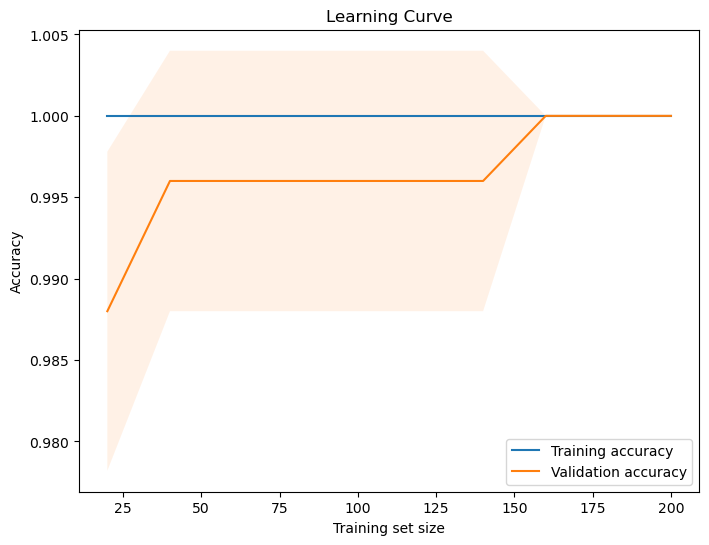

In [628]:
train_sizes, train_scores, val_scores = learning_curve(
    SVC(kernel='linear', C=0.1, probability=False),        
    Train_SSMCF7_pca, y,
    cv=5,                     
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)   
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Training accuracy")
plt.plot(train_sizes, val_mean, label="Validation accuracy")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1)
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [629]:
svm_model = SVC(kernel='linear', C=0.1, probability=False)
svm_model.fit(Train_SSMCF7_pca, y)

y_test_pred = svm_model.predict(Test_SSMCF7_pca)

label_map = {0: 'Norm', 1: 'Hypo'}
y_test_pred_mapped = [label_map[pred] for pred in y_test_pred]


output_df = pd.DataFrame({
    'Sample': range(1, len(df_SSMCF7_Test.T) + 1), 
    'PredictedLabel': y_test_pred_mapped
})
output_df.to_csv('SmartSeqMCF7_predictions.txt', sep='\t', header=False, index=False)

### HCC1806

Predictions on SmartSeq MCF7 using SVM with (kernel ='linear', C=0.1)

In [632]:
Train_SSHCC1806_log = np.log1p(df_SSHCC1806_Train_T)
Test_SSHCC1806_log = np.log1p(df_SSHCC1806_Test.T)

pca = PCA(n_components=30)
Train_SSHCC1806_pca = pca.fit_transform(Train_SSHCC1806_log)
Test_SSHCC1806_pca = pca.transform(Test_SSHCC1806_log)

y_labels = df_meta_SSHCC1806.loc[df_SSHCC1806_Train_T.index, 'Condition']
y = [0 if element == "Normo" else 1 for element in y_labels]

print(Train_SSHCC1806_log.shape, np.array(y).shape, Train_SSHCC1806_pca.shape)
print(y)

(182, 3000) (182,) (182, 30)
[0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0]


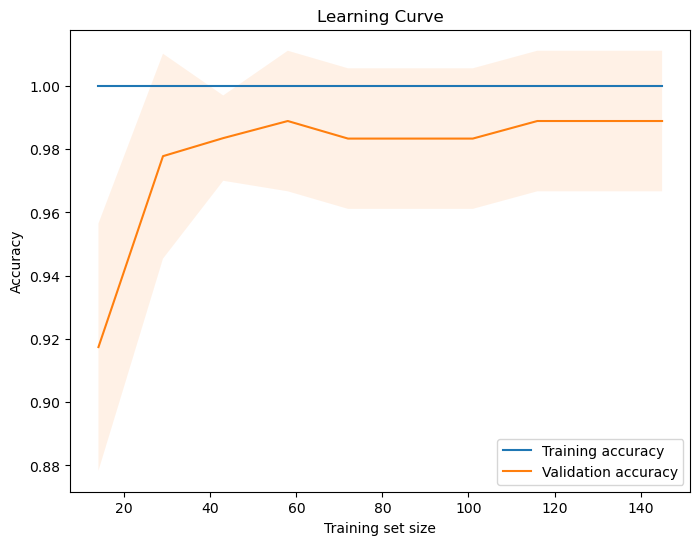

In [633]:
train_sizes, train_scores, val_scores = learning_curve(
    SVC(kernel='linear', C=0.1, probability=False),        
    Train_SSHCC1806_pca, y,
    cv=5,                     
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)   
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Training accuracy")
plt.plot(train_sizes, val_mean, label="Validation accuracy")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1)
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [634]:
svm_model = SVC(kernel='linear', C=0.1, probability=False)
svm_model.fit(Train_SSHCC1806_pca, y)

y_test_pred = svm_model.predict(Test_SSHCC1806_pca)

label_map = {0: 'Norm', 1: 'Hypo'}
y_test_pred_mapped = [label_map[pred] for pred in y_test_pred]

output_df = pd.DataFrame({
    'Sample': range(1, len(df_SSHCC1806_Test.T) + 1),   
    'PredictedLabel': y_test_pred_mapped
})
output_df.to_csv('SmartSeqHCC1806_predictions.txt', sep='\t', header=False, index=False)


## DropSeq

### MCF7

Predictions on DropSeq MCF7 using Kernel SVM with ('C': 100, 'gamma': 0.001, 'kernel': 'rbf'), we shuffled the dataset because initially it was perfectly separated in two groups: the first one including only 0 labes and second one only 1s. This raised a problem during the plotting of the learning curve because, during the first stes, it was selecting elements with the same label.

In [666]:
df_DSMCF7 = pd.read_csv("DropSeq/MCF7/MCF7_Filtered_Normalised_3000_Data_train.txt", sep=r"\s+", engine="python", index_col=0)
X_train = df_DSMCF7.T.values
y_raw = df_DSMCF7.T.index.values

np.random.seed(0)
indices = np.arange(len(X_train))
np.random.shuffle(indices)

X_train_shuffle = X_train[indices]
y_raw_shuffle = y_raw[indices]

X_test = df_DSMCF7_Test.T.values

pca = PCA(n_components = 50)
Train_DSMCF7_pca = pca.fit_transform(X_train_shuffle)
Test_DSMCF7_pca = pca.transform(X_test)

y_labels = [element.strip('""').split("_")[1] for element in y_raw_shuffle]
y = [0 if element == "Normoxia" else 1 for element in y_labels]

print(X_train.shape, y_raw.shape, X_train_shuffle.shape, y_raw_shuffle.shape, Train_DSMCF7_pca.shape)

(21626, 3000) (21626,) (21626, 3000) (21626,) (21626, 50)


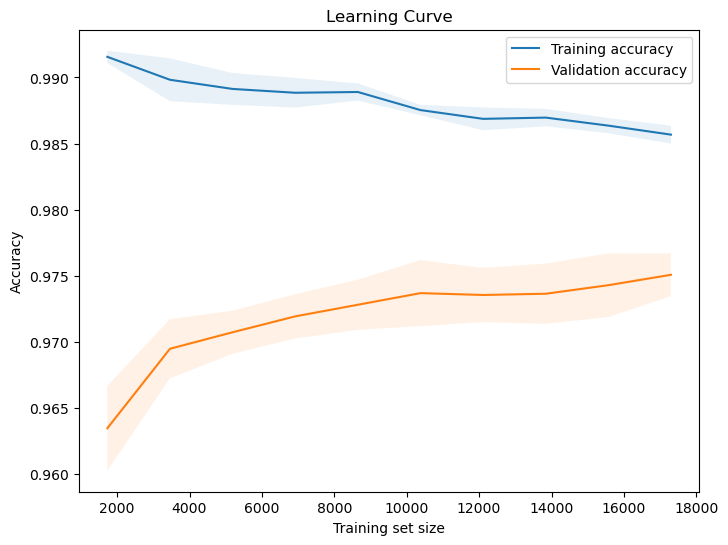

In [667]:
train_sizes, train_scores, val_scores = learning_curve(
    SVC(kernel='rbf', C=100, gamma=0.001, probability=False),        
    Train_DSMCF7_pca, y,
    cv=5,                     
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)   
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Training accuracy")
plt.plot(train_sizes, val_mean, label="Validation accuracy")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1)
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [668]:
svm_model = SVC(kernel='rbf', C=100,gamma=0.001, probability=False)
svm_model.fit(Train_DSMCF7_pca, y)

y_test_pred = svm_model.predict(Test_DSMCF7_pca)


label_map = {0: 'Norm', 1: 'Hypo'}
y_test_pred_mapped = [label_map[pred] for pred in y_test_pred]


output_df = pd.DataFrame({
    'Sample': range(1, len(df_DSMCF7_Test.T) + 1),   
    'PredictedLabel': y_test_pred_mapped
})
output_df.to_csv('DropSeqMCF7_predictions.txt', sep='\t', header=False, index=False)

### HCC1806

Predictions on DropSeq HCC1806 using Kernel SVM with ('C': 1, 'gamma': 'scale', 'kernel': 'rbf')

In [669]:
df_DSHCC1806 = pd.read_csv("DropSeq/HCC1806/HCC1806_Filtered_Normalised_3000_Data_train.txt", sep=r"\s+", engine="python", index_col=0)
X_train = df_DSHCC1806.T.values
y_raw = df_DSHCC1806.T.index.values

np.random.seed(0)
indices = np.arange(len(X_train))
np.random.shuffle(indices)

X_train_shuffle = X_train[indices]
y_raw_shuffle = y_raw[indices]

X_test = df_DSHCC1806_Test.T.values

pca = PCA(n_components = 50)
Train_DSHCC1806_pca = pca.fit_transform(X_train_shuffle)
Test_DSHCC1806_pca = pca.transform(X_test)

y_labels = [element.strip('""').split("_")[1] for element in y_raw_shuffle]
y = [0 if element == "Normoxia" else 1 for element in y_labels]

print(X_train.shape, y_raw.shape, X_train_shuffle.shape, y_raw_shuffle.shape, Train_DSHCC1806_pca.shape)

(14682, 3000) (14682,) (14682, 3000) (14682,) (14682, 50)


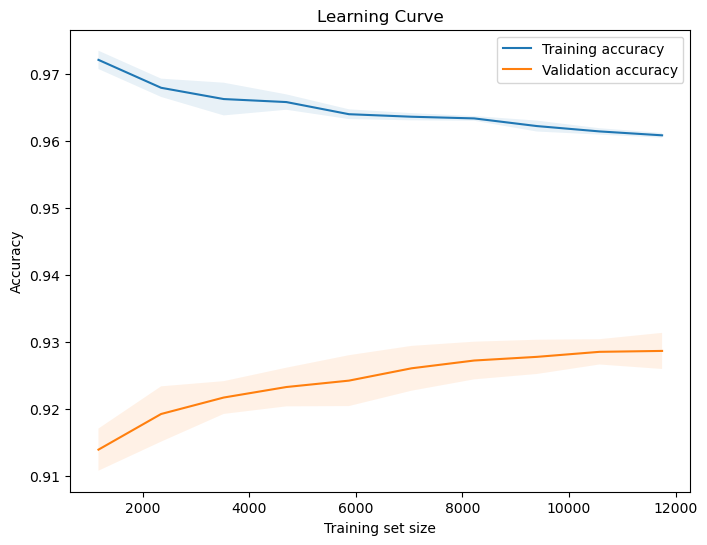

In [670]:
train_sizes, train_scores, val_scores = learning_curve(
    SVC(kernel='rbf', C=1, gamma='scale' , probability=False),        
    Train_DSHCC1806_pca, y,
    cv=5,                     
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)   
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Training accuracy")
plt.plot(train_sizes, val_mean, label="Validation accuracy")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1)
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [671]:
svm_model = SVC(kernel='rbf', C=1, gamma='scale', probability=False)
svm_model.fit(Train_DSHCC1806_pca, y)

y_test_pred = svm_model.predict(Test_DSHCC1806_pca)

label_map = {0: 'Norm', 1: 'Hypo'}
y_test_pred_mapped = [label_map[pred] for pred in y_test_pred]

output_df = pd.DataFrame({
    'Sample': range(1, len(df_DSHCC1806_Test.T) + 1),   
    'PredictedLabel': y_test_pred_mapped
})
output_df.to_csv('DropSeqHCC1806_predictions.txt', sep='\t', header=False, index=False)

# Conclusions 

We began by exploring all four datasets, examining graphs, distributions, and the biological meaning of features and samples. This exploration helped us understand the dataset structures and informed the preprocessing steps, which included duplicate checks, quality control, high-variance feature selection, and normalization to make the data more suitable for machine learning.

In the unsupervised learning stage, we applied PCA and clustering. For the MCF7 datasets, PCA revealed that much of the variance corresponded to the label differences, leading to clear separation of the two classes, especially in the SmartSeq case. In contrast, the HCC1806 datasets showed weaker separation, suggesting subtler biological differences. Clustering results confirmed these findings, again highlighting better performance for SmartSeq and for MCF7 cells compared to HCC1806.

Supervised learning involved testing multiple models: SVM, Kernel SVM, KNN, Logistic Regression, Naive Bayes, and Random Forest. After hyperparameter tuning with grid search and evaluation via 5-fold cross-validation, SVM and Kernel SVM consistently achieved the best results. Specifically, Kernel SVM reached 97.5% accuracy on MCF7 DropSeq and 94% on HCC1806 DropSeq, while in the SmartSeq datasets, multiple models (including SVM) achieved 100% accuracy on MCF7 and 98.6% on HCC1806. Overall, SmartSeq outperformed DropSeq, and MCF7 proved easier to classify than HCC1806.

Finally, our predictions were made by the following models (trained on the whole training sets):

- __DropSeq MCF7__: Kernel SVM ('C': 100, 'gamma': 0.001, 'kernel': 'rbf')

- __DropSeq HCC180__: Kernel SVM ('C': 1, 'gamma': 'scale', 'kernel': 'rbf')

- __SmartSeq MCF7__: SVM ('C': 0.01, 'kernel': 'linear')

- __SmartSeq HCC1806__: SVM ('C': 0.01, 'kernel': 'linear')